In [1]:
import pandas as pd
import numpy as np
import os
from datetime import datetime
import matplotlib.pyplot as plt
import networkx as nx
import copy
from dotenv import load_dotenv
import seaborn as sns

load_dotenv()

print(os.getenv("COMTRADE_API_KEY"))

d4457e079e6240cc8f74def00b4e192f


In [2]:
nat_gas_codes = {271111: 'Natural gas, liquefied',
                 271121: 'Natural gas, gaseous'}

year_list = list(range(2010, datetime.now().year)) # list of all years from 2010 to now

folder_name = 'nat_gas_2000-2025_Trade_data'


In [3]:
dfr = pd.read_parquet(os.path.join(folder_name, 'nat_gas_trade_df'), engine='pyarrow') #df for dollar analysis

dfr_kg = pd.read_parquet(os.path.join(folder_name, 'nat_gas_trade_df_kg'), engine='pyarrow') #df for kg analysis
dfr.shape, dfr_kg.shape

((91594, 28), (83556, 29))

In [4]:
print('How many n/a values we have in columns of each df:')
dfs_list = [dfr, dfr_kg]

for df in dfs_list:
    print('-'*50, f'\n ')
    for i in df.columns:
        if df[i].isna().sum():
            print(f'column {i} has {df[i].isna().sum()} n/a columns ({df[i].isna().sum()*100/df.shape[0]}%).')

How many n/a values we have in columns of each df:
-------------------------------------------------- 
 
column qty has 3466 n/a columns (3.784090660960325%).
column altQty has 3466 n/a columns (3.784090660960325%).
column netWgt has 1428 n/a columns (1.5590540865122169%).
column qty_type has 21129 n/a columns (23.068104897700724%).
-------------------------------------------------- 
 
column qty has 2508 n/a columns (3.0015797788309637%).
column altQty has 2508 n/a columns (3.0015797788309637%).
column qty_type has 15327 n/a columns (18.343386471348555%).


Now it is needed to prepare data in each df to build weighted directed graph.

In [5]:
print(dfr.shape, dfr_kg.shape, dfr.shape[0] -  dfr_kg.shape[0])
diff = [index for index in dfr.index if index not in dfr_kg.index] #what indexes we lost in dfr_kg
print(len(diff))
print(f'For analysis in kg we lost {dfr.loc[diff, :].primaryValue.sum()/10**9:.4f} billions of dollars \
       ({dfr.loc[diff, :].primaryValue.sum()*100/ dfr.primaryValue.sum():.4f}% of dataset)')

(91594, 28) (83556, 29) 8038
8038
For analysis in kg we lost 592.5442 billions of dollars        (7.5949% of dataset)


In [6]:
dfr.columns

Index(['period', 'refYear', 'refMonth', 'reporterCode', 'flowCode',
       'partnerCode', 'classificationCode', 'cmdCode', 'customsCode',
       'motCode', 'qtyUnitCode', 'qty', 'isQtyEstimated', 'altQtyUnitCode',
       'altQty', 'isAltQtyEstimated', 'netWgt', 'isNetWgtEstimated',
       'primaryValue', 'isAggregate', 'reporter', 'partner', 'flow',
       'transport', 'qty_type', 'alt_qty_type', 'customs_type', 'type'],
      dtype='object')

In [7]:
#Preparing data for directed graph
for df in dfs_list:
    df['source'] = np.where(df.flow == 'Export', df.reporter, df.partner) 
    # if export - source is reporter (reporter exports to partner), if import - source is partner (partner exports to reporter)
    df['target'] = np.where(df.flow == 'Export', df.partner, df.reporter) # similar reversed logic for target

In [8]:
# creating graphs for each year from our dfs with 2 types of weight of edges: trade in dollars and trade in kilograms. 

dfs_cols = {'primaryValue': dfr, 'netWgt': dfr_kg}
dfs_list=[dfr, dfr_kg]
gas_types = list(dfr.type.unique())
graphs = {gas: {'primaryValue': {}, 'netWgt': {}} for gas in gas_types}
weights = copy.deepcopy(graphs)

for gas_type in gas_types:
    for col, df in dfs_cols.items():
        for year in year_list:
            dfg = df[df.type == gas_type]
            dfgy = dfg[dfg.refYear == year]

            G = nx.from_pandas_edgelist(df = dfgy, source = 'source', 
                                    target = 'target', edge_attr=True, create_using=nx.DiGraph)

            edges = G.edges()
            weight = np.array([G[u][v][col] for u, v in edges])

            
            graphs[gas_type][col][f'G_{year}'] = G
            weights[gas_type][col][f'G_{year}'] = weight

In [9]:
graphs

{'gaseous': {'primaryValue': {'G_2010': <networkx.classes.digraph.DiGraph at 0x150d34710>,
   'G_2011': <networkx.classes.digraph.DiGraph at 0x150d1f890>,
   'G_2012': <networkx.classes.digraph.DiGraph at 0x153035f50>,
   'G_2013': <networkx.classes.digraph.DiGraph at 0x152fe6bd0>,
   'G_2014': <networkx.classes.digraph.DiGraph at 0x153037790>,
   'G_2015': <networkx.classes.digraph.DiGraph at 0x153097b10>,
   'G_2016': <networkx.classes.digraph.DiGraph at 0x153042110>,
   'G_2017': <networkx.classes.digraph.DiGraph at 0x1530f5790>,
   'G_2018': <networkx.classes.digraph.DiGraph at 0x153083d90>,
   'G_2019': <networkx.classes.digraph.DiGraph at 0x153074510>,
   'G_2020': <networkx.classes.digraph.DiGraph at 0x1530812d0>,
   'G_2021': <networkx.classes.digraph.DiGraph at 0x153074c90>,
   'G_2022': <networkx.classes.digraph.DiGraph at 0x15317ffd0>,
   'G_2023': <networkx.classes.digraph.DiGraph at 0x1530c6b50>,
   'G_2024': <networkx.classes.digraph.DiGraph at 0x1531e2910>,
   'G_2025': 

In [10]:
#parameters to make nice graph

def get_layout(G:nx.DiGraph):
    "Function to create nice layout for a given graph"
    
    return nx.spring_layout(G, k=1.4, scale=2)

def get_sizes(G:nx.DiGraph, col: str, scale=100):

    "Function to adjust size of nodes to their weighted degree"

    weighted_degrees = dict(G.degree(weight=col))
    degrees = np.array(list(weighted_degrees.values()))
    sizes = np.sqrt(degrees)/scale
    return sizes

def get_width(G:nx.DiGraph, weight, scale=10000):
    "Function to adjust size of nodes to their weighted degree"

    return np.sqrt(weight)/scale

def get_color(G: nx.DiGraph, weight):

    "Function that colors importers in green and exporters in red"

    import_weights = {}
    export_weights = {}

    for node in G.nodes():
        import_weights[node] = sum(d[weight] for u, v, d in G.in_edges(node, data=True))
        export_weights[node] = sum(d[weight] for u, v, d in G.out_edges(node, data=True))

    colors = []
    for node in G:
        if import_weights[node] > export_weights[node]:
            colors.append('green')  
        else:
            colors.append('red') 

    return colors


def draw_graph(type: str, measure: str, year: int):

    "Function that draws final graw with all settings given by previous functions"
    
    G = graphs[type][measure][f'G_{year}']
    weight = weights[type][measure][f'G_{year}']
    
    plt.figure(figsize=(10,7))
    nx.draw(G, get_layout(G), node_size=get_sizes(G, measure), width=get_width(G, weight=weight), 
        edge_color='grey',  node_color=get_color(G, measure), with_labels=True, font_size=8)


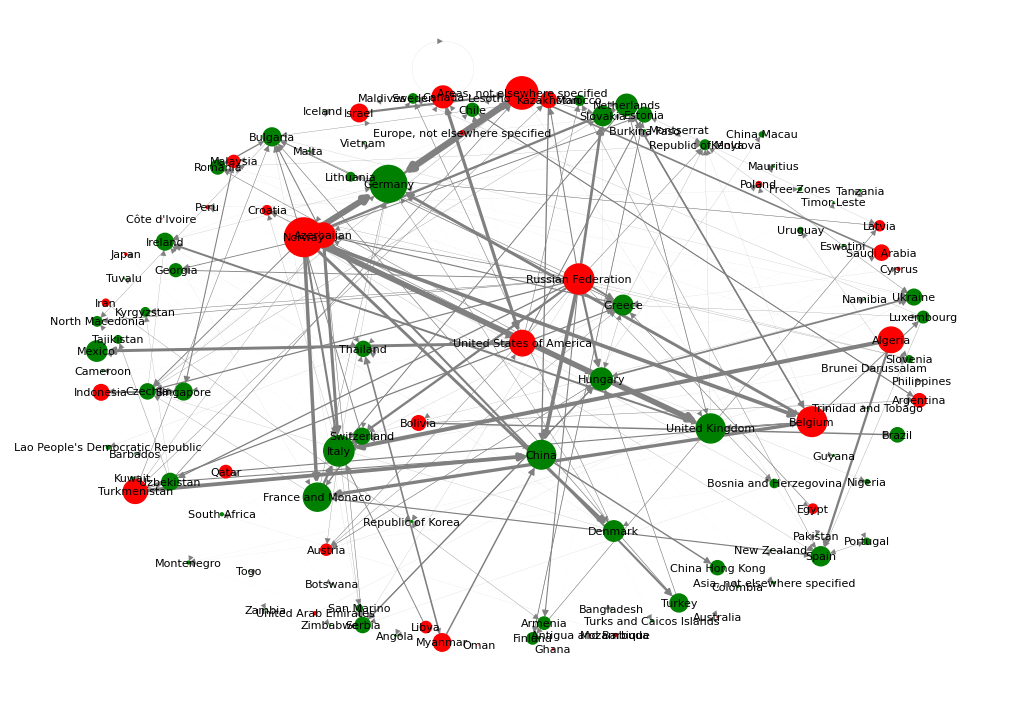

In [11]:
draw_graph('gaseous', 'primaryValue', 2024)

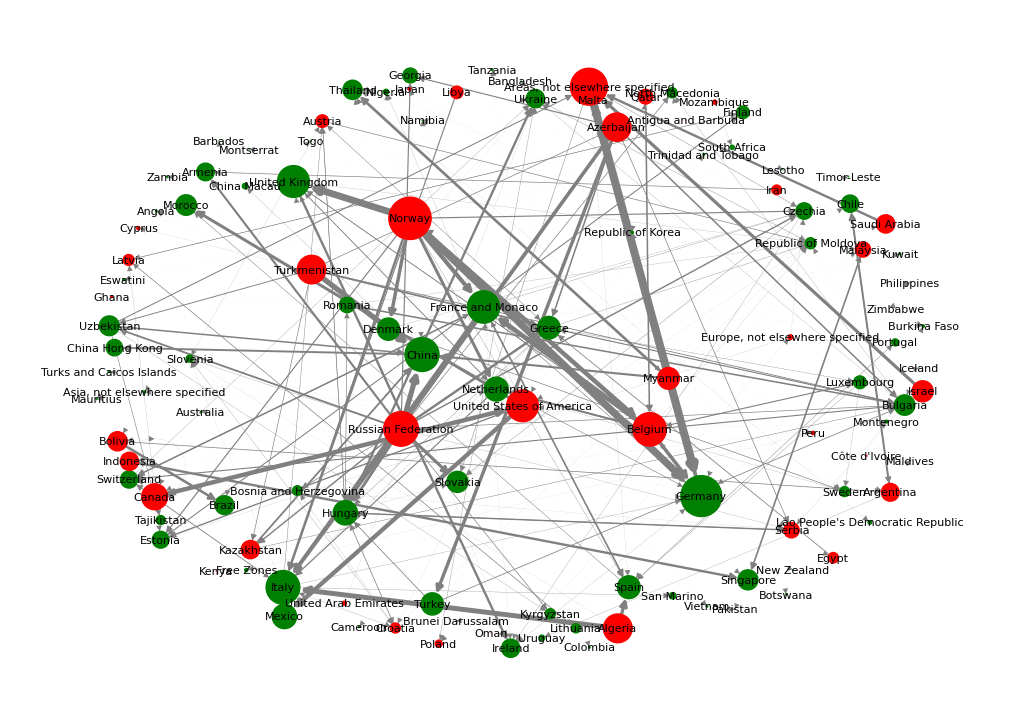

In [12]:
draw_graph('gaseous', 'netWgt', 2024)

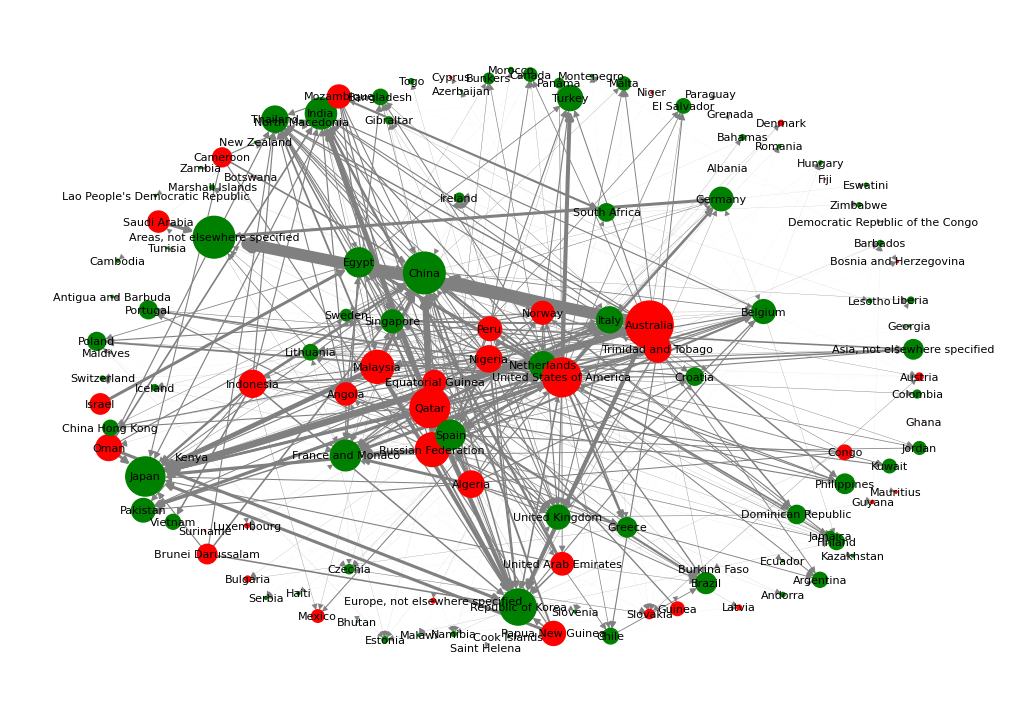

In [13]:
draw_graph('liquefied', 'netWgt', 2024)

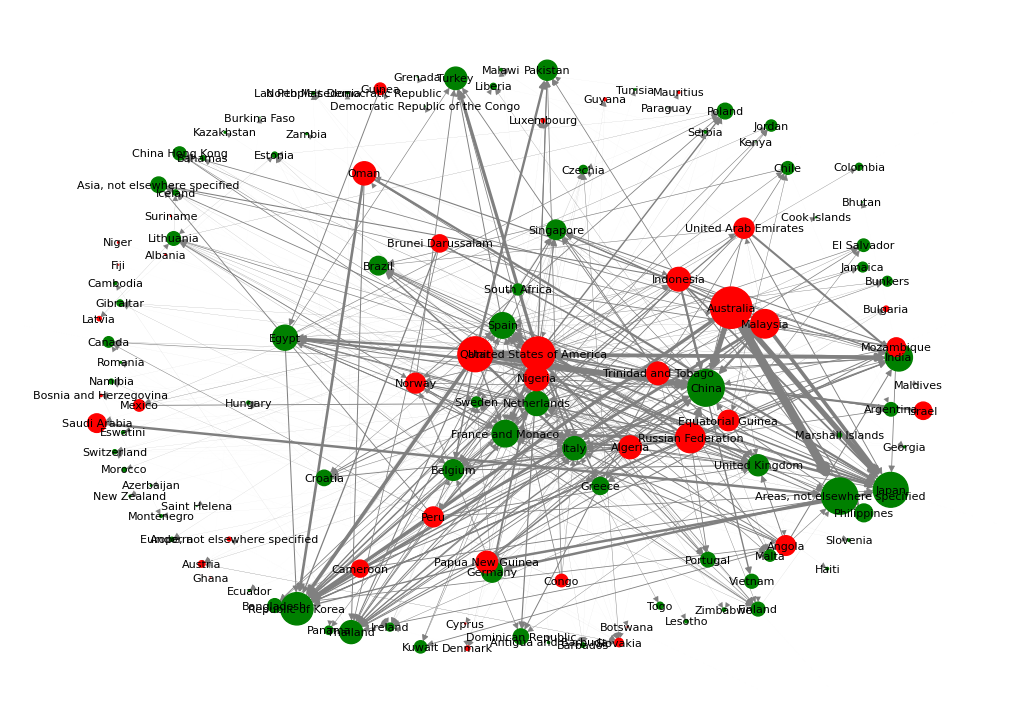

In [14]:
draw_graph('liquefied', 'primaryValue', 2024)

In [15]:
def global_efficiency(G: nx.DiGraph, weight: str):

    """
    Function that returns the efficiency of the graph. It appeared that the efficiency metric in networkx is pretty limited and does not
    work with directed and weighted graphs. This metric, based on the same principle, adjusts for weight.
    Inputs: graph, its weight attribute.
    Output: efficiency of the graph.
    Note: for the inverted graph, it was required to invert weights as more trade is better, not worse, as the shortest path treats it.
    """

    num_nodes = G.number_of_nodes()
    all_pairs = num_nodes*(num_nodes-1)
    efficiency_sum = 0

    for source, targets in nx.shortest_path_length(G, weight=weight):
        for target, distance in targets.items():

            if source != target:
                if distance > 0:
                    efficiency_sum += 1 / distance

    return efficiency_sum/all_pairs

In [16]:
def global_efficiency_log_normalized(G: nx.DiGraph, weight: str):

    """
    Global_efficiency above gives extremely small values, which appeared because 
    1. the shortest path is inverted, not the weights, and 2. the distribution of weights in natgas is catastrophically heavy-tailed:
    plenty of small trades with a few enormous. This function fixes the first effects and smoothes the second.
    """

    G_cost = G.copy()
    
    max_weight = max(d[weight] for u, v, d in G.edges(data=True))
    log_max = np.log2(max_weight + 1) # +1 if the trade is 0

    for u, v, data in G_cost.edges(data=True):
        trade_vol = data.get(weight, 0)
        
        if trade_vol > 0:
            log_weight = np.log2(trade_vol + 1)
            data['cost'] = log_max / log_weight
        else:
            G_cost.remove_edge(u, v)

    #Now the same as in the efficiency before
    num_nodes = G_cost.number_of_nodes()
    
    all_pairs = num_nodes * (num_nodes - 1)
    efficiency_sum = 0

    for source, targets in nx.shortest_path_length(G_cost, weight='cost'):
        for target, distance in targets.items():
            if source != target:
                efficiency_sum += 1 / distance

    return efficiency_sum / all_pairs

In [17]:
def get_metrics(func:nx.function, weights:bool) -> pd.DataFrame:

    """
    This function calculates some metrics of the graph based on the given function to store it in comfortable df.
    Input: function; whether it takes weight.
    Output: DataFrame 
    """

    df = [] #list is more memory efficient than doing using pd.concat()
    for gas_type in gas_types:
        for col in list(dfs_cols.keys()):
            for year in year_list:

                G = graphs[gas_type][col][f'G_{year}']

                if weights:
                    weight = func(G, weight=col)
                else:
                    weight = func(G)
                
                df.append({'type': gas_type, 
                           'measure': col, 
                           'year': year, 
                           'function': str(func.__name__),
                           'value': weight})
    
    return(pd.DataFrame(df))



get_metrics(func = nx.average_clustering, weights=True).head()

,type,measure,year,function,value
0,gaseous,primaryValue,2010,average_clustering,0.000567
1,gaseous,primaryValue,2011,average_clustering,0.000544
2,gaseous,primaryValue,2012,average_clustering,0.000718
3,gaseous,primaryValue,2013,average_clustering,0.000861
4,gaseous,primaryValue,2014,average_clustering,0.000518


In [18]:
functions_list = {nx.average_clustering: True, nx.degree_assortativity_coefficient: True,
                  nx.reciprocity: False, nx.density: False, global_efficiency: True, global_efficiency_log_normalized: True}

dfs_list = []
for function, weight in functions_list.items():
    dfs_list.append(get_metrics(func = function, weights=weight))


df_metrics = pd.concat(dfs_list, ignore_index=True)
df_metrics = df_metrics.pivot(columns='function', index=['type', 'measure', 'year'], values='value').reset_index()
df_metrics.tail()

function,type,measure,year,average_clustering,degree_assortativity_coefficient,density,global_efficiency,global_efficiency_log_normalized,reciprocity
59,liquefied,primaryValue,2021,0.000517,0.084719,0.033273,0.000108,0.099158,0.222597
60,liquefied,primaryValue,2022,0.000575,0.146278,0.035784,0.000111,0.102066,0.219178
61,liquefied,primaryValue,2023,0.000535,0.136547,0.037290,0.000194,0.108718,0.212766
62,liquefied,primaryValue,2024,0.000583,0.085258,0.038140,0.000265,0.112208,0.248387
63,liquefied,primaryValue,2025,0.000613,-0.008148,0.030323,0.001403,0.095818,0.208511


In [19]:
df_metrics['type_measure'] = df_metrics['type'] + ', ' + df_metrics['measure']  #to compare everything on one graph
df_metrics.head() 

function,type,measure,year,average_clustering,degree_assortativity_coefficient,density,global_efficiency,global_efficiency_log_normalized,reciprocity,type_measure
0,gaseous,netWgt,2010,0.000633,0.097043,0.019139,0.000233,0.032167,0.363636,"gaseous, netWgt"
1,gaseous,netWgt,2011,0.000764,0.146084,0.020485,0.000764,0.041434,0.324561,"gaseous, netWgt"
2,gaseous,netWgt,2012,0.000983,0.204356,0.017414,0.000406,0.032139,0.234146,"gaseous, netWgt"
3,gaseous,netWgt,2013,0.000676,0.181411,0.018726,0.000602,0.040070,0.320675,"gaseous, netWgt"
4,gaseous,netWgt,2014,0.000560,0.209447,0.018243,0.000397,0.036618,0.314894,"gaseous, netWgt"


In [20]:
def plot_metric(metric: str, df = df_metrics):
    "This function creates a lineplot for a given metric with 4 hues based on the type of gas and measurement"
    plt.figure(figsize=(12,6))

    sns.pointplot(data = df, 
                x='year', y=metric, errorbar = None, hue='type_measure')
    plt.ylabel('Value', size=12)
    plt.xlabel('Year', size=12)
    plt.grid(True)
    plt.title('Evolution of ' + metric + ' for all years')

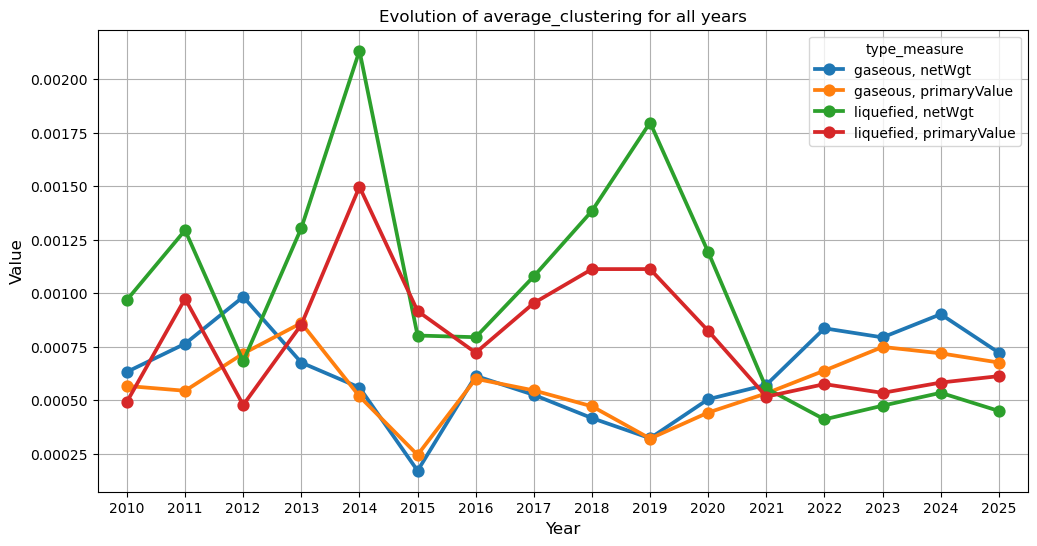

In [21]:
plot_metric('average_clustering')

Explanations:
A clustering coefficient is a measure of the degree to which nodes in a graph tend to cluster together. A cluster is a group of 3 nodes (a triangle). The higher clustering, the higher chance that if country A trades with countries B and C, countries B and C trade with each other. So, trades are not simply for end-use, but the flow is high among different countries, with higher interconnectedness.
We see that gas has a very low weighted clustering coefficient - there are no huge hubs, gas is just bought directly by the importer from the exporter, and then consumed. 

Throughout history, liquified gas has shown higher clustering - it has been traded more internationally compared to direct pipes from producers to consumers of gaseous natural gas. However, in 2020-2021, the clustering coefficient for liquified type went down abruptly and is now even lower than for gaseous type without noticeable tendency to return. It indicates the "narrowing" of the market - the globalization of trade reduced.


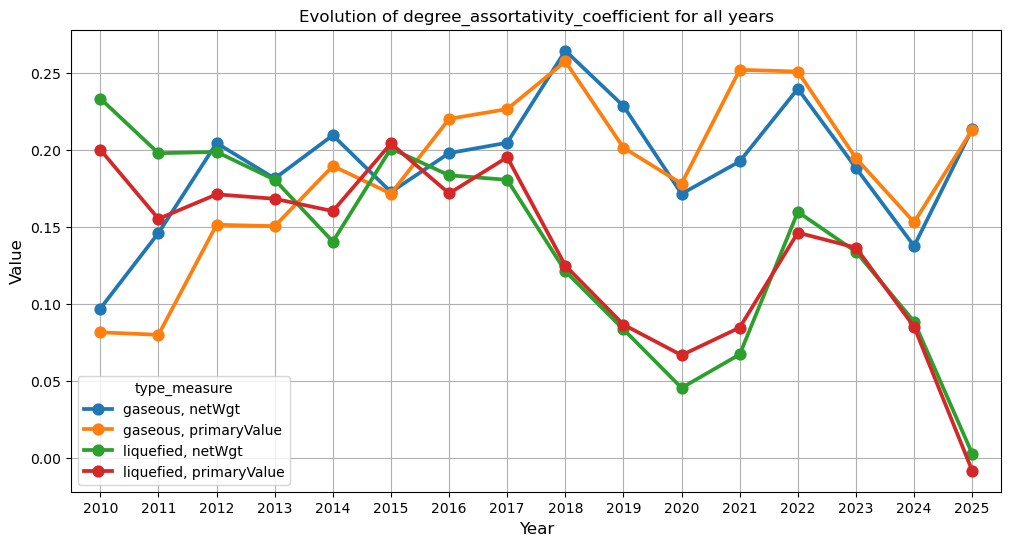

In [22]:
plot_metric('degree_assortativity_coefficient')

Degree assortativity coefficient measures the rate of assortativity in the network: higher coefficient (up to +1) means that big countries (by total trade) trade primarily with big ones and small countries trade with small ones; lower coefficient (up to -1) means that big countries trade more with small countries (core-periphery/star structure: a lot of small countries connected to chief one). Close to 0 values indicate that there are no such tendencies: random distribution of trades.

Gaseous type demonstrates moderate positive values: inter-country pipes facilitate the flow of large amounts directly to the consumer, which is beneficial for both sides. It aligns with the result received above. Still, values are not critical and do not demonstrate a direct trend toward deglobalization.

Liquefied gas has shown 2 jumps in the direction of random distribution; however, the data for 2025 is not complete yet to be sure in these values. This type of gas does not demonstrate a high degree of direct consumer-supplier relationships. However, values are not negative to indicate the establishment of important hubs (which would be good for international trade). Additionally, time series for liquified gas are relatively volatile - the international market is young for liquified type of gas, and it remains to be seen what tendencies will establish in the future.

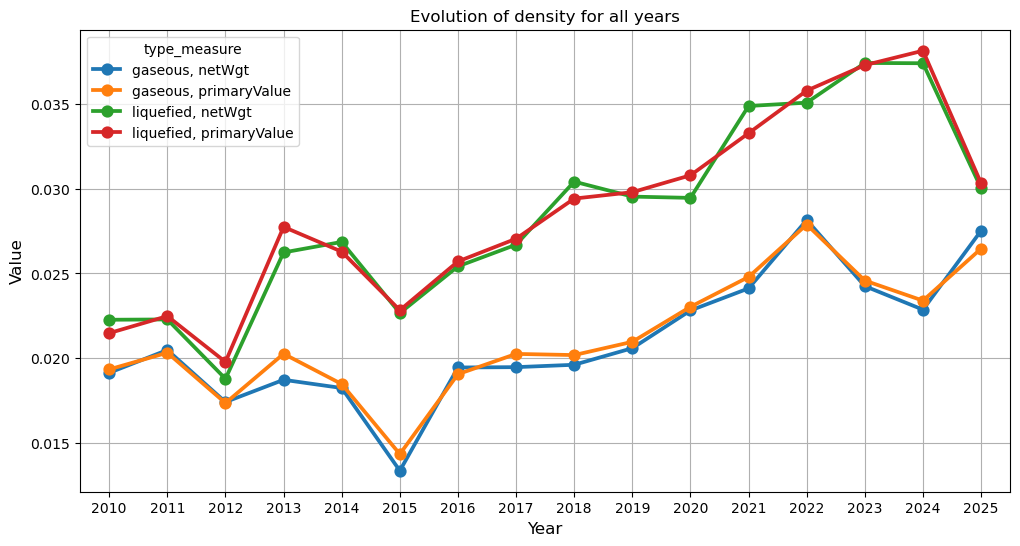

In [23]:
plot_metric('density') #Note - density does not accept weights.

Density is calculated as (Number of existing edges in the network)/(Number of possible edges in the network). So, it is an answer to a question: "Of all the possible trade connections that could exist between countries ( N*(N-1) for directed graph, where N is number of nodes), how many actually do exist?" Rising density indicates about growing number of connections between countries. Remember: density is unweighted!!!

Liquified gas permanently shows higher density, which is expected due to the reasons mentioned above. In recent years, we have seen a growing density for both types of gas, which could indicate growing globalization. However, we must remember that this metric is unweighted: although new routes are established, they are not necessarily meaningful. The weighted metrics above do not show the trend toward higher interconnectedness. So, despite the network's topology is improving, we cannot say the same about the weighted graph.

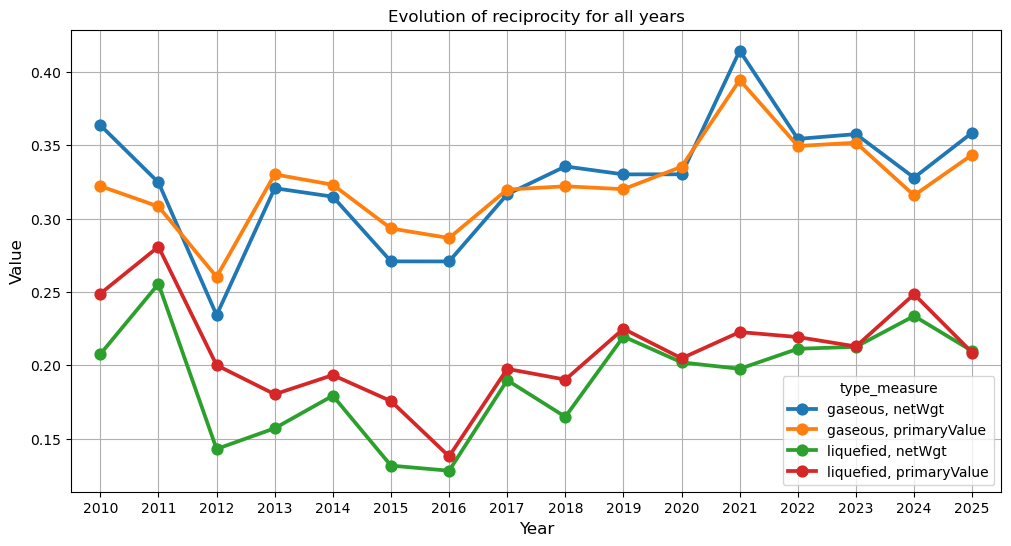

In [24]:
plot_metric('reciprocity') #Note - reciprocity does not accept weights.

Reciprocity = (Number of reciprocal edges)/(Total number of edges). So, it is a percentage of mutual trades in the network. Surprisingly, it is not close to 0 for both types, and even higher for the gaseous type than for the liquified one. 
Often, countries can send each other gas they saved in storage - we see it is popular for the gaseous type. I believe most of the mutual trades occurred in the EU (you can watch the network at the start of the file). However, it is, as density, an unweighted metric - the existence of an edge does not imply its importance.

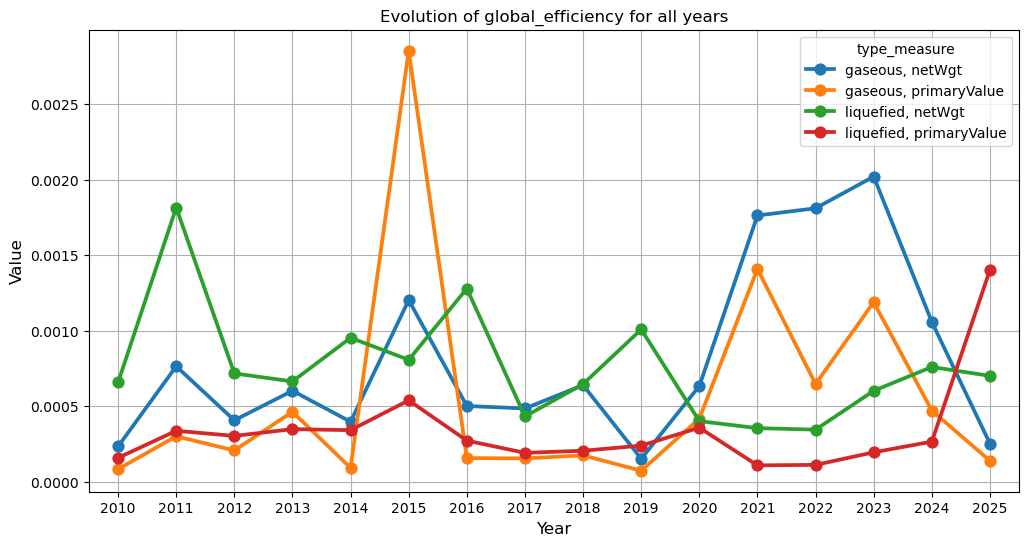

In [25]:
plot_metric('global_efficiency')

Values are minimal, but we know the formula is correct: we need to consider only the evolution of values.
Higher efficiency means better sharing of information in the network - in terms of trade, it means countries can reach each other more easily, trade is internationalized. Unfortunately, we do not see this for both types of gas: sometimes spikes can be noticed; however, they are temporary and likely a product of structural changes of big players' trades, not of better conditions of trade. 

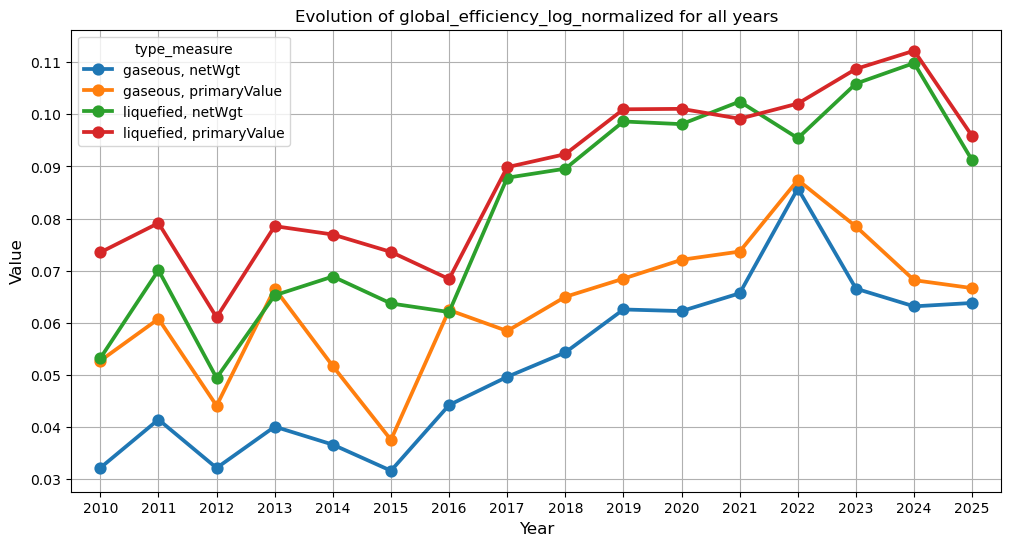

In [26]:
plot_metric('global_efficiency_log_normalized')

Logarithmically normalized efficiency shows a much better picture: efficiency is rising over the long period. However, after 2022, the gaseous type shows a reverse tendency after the disruption in Russia-EU trade. 
Log-efficiency showing better results supports the assumption of a discrepancy between the topology of the network and characteristics adjusted to weight. Major countries in the network does not increase efficiency through their trade; on the contrary, they decrease it, as large trades are too concentrated.

We should not forget that this efficiency logarithmically normalizes: the real world is not. But it again shows the problem is not in the distribution of edges but in the distribution of trades.

In [27]:
df_metrics[list(df_metrics.columns[3:-1:])].corr()

function,average_clustering,degree_assortativity_coefficient,density,global_efficiency,global_efficiency_log_normalized,reciprocity
function,,,,,,
average_clustering,1.000000,-0.149119,0.182319,0.071641,0.195031,-0.401472
degree_assortativity_coefficient,-0.149119,1.000000,-0.474899,0.081944,-0.469188,0.339920
density,0.182319,-0.474899,1.000000,-0.130499,0.921082,-0.378788
global_efficiency,0.071641,0.081944,-0.130499,1.000000,-0.131527,0.163353
global_efficiency_log_normalized,0.195031,-0.469188,0.921082,-0.131527,1.000000,-0.361610
reciprocity,-0.401472,0.339920,-0.378788,0.163353,-0.361610,1.000000


Correlations between metrics are not high (small sample). However, the correlation between global_efficiency_log_normalized and density is higher than 0.9, which implies that more connections between countries generally increase the speed of information sharing in the network. However, the sample is not large enough to conclude something.

In [66]:
def get_centralities(func: nx.function, gas_type: str, measure: str, year: int) -> pd.DataFrame:

    """
    This function calculates centralities of each country in the given graph and returns a df with countries as indices.
    Inputs: function in networkx for centrality calculation, type of gas, type of measure, and year of observation.
    Output: df with countries as indices and a corresponding centrality value. 
    """
    
    G = graphs[gas_type][measure][f'G_{year}']

    if func.__name__ == 'pagerank': # for this function changing direction gives more meaningful results

        G_reversed = G.reverse() 
        centralities = func(G_reversed, weight=measure, alpha=0.85)

    elif func.__name__ == 'katz_centrality_numpy':
        for u, v, d in G.edges(data=True):
            d['log_weight'] = np.log1p(d['primaryValue'])
            centralities = func(G, weight='log_weight', alpha = 0.06)
    
    else:
        centralities = func(G, weight=measure)

        
    df = pd.DataFrame(data = {func.__name__: centralities.values()}, index = centralities.keys())
    
    return df



In [67]:
centralities_list = [nx.pagerank, nx.constraint, nx.katz_centrality_numpy]
df_centr = {gas_type: [] for gas_type in gas_types}

for gas_type, df_list in df_centr.items():    
    for func in centralities_list:
        df = get_centralities(func=func, gas_type = gas_type, measure = 'primaryValue', year=2024)
        df_list.append(df)

dfs_centr = {gas_type: pd.concat(dfs_list, axis=1) for gas_type, dfs_list in df_centr.items()}
dfs_centr['gaseous'].head()

,pagerank,constraint,katz_centrality_numpy
Iran,0.002014,1.000000,0.004443
Armenia,0.001870,0.834579,0.013352
Russian Federation,0.034665,0.195537,0.004443
Croatia,0.002446,0.611271,0.026487
Bosnia and Herzegovina,0.002705,0.814791,0.029766


In [68]:
for centrality in ['pagerank', 'katz_centrality_numpy']:
    for gas_type in gas_types:
            print(f"""Top 5 countries for by {centrality} centrality for {gas_type} type of gas:
                {dfs_centr[gas_type][centrality].nlargest(5)}""")

Top 5 countries for by pagerank centrality for gaseous type of gas:
                United States of America    0.189585
Canada                      0.163472
Norway                      0.068079
Sweden                      0.059743
Denmark                     0.046593
Name: pagerank, dtype: float64
Top 5 countries for by pagerank centrality for liquefied type of gas:
                South Africa                0.099175
Mozambique                  0.096169
United States of America    0.094371
Trinidad and Tobago         0.051304
Malaysia                    0.050496
Name: pagerank, dtype: float64
Top 5 countries for by katz_centrality_numpy centrality for gaseous type of gas:
                Argentina    0.438940
Chile        0.423119
Uruguay      0.384881
Singapore    0.355706
Indonesia    0.194877
Name: katz_centrality_numpy, dtype: float64
Top 5 countries for by katz_centrality_numpy centrality for liquefied type of gas:
                Barbados              0.517877
Dominican Republi

In [69]:
for gas_type in gas_types:
        print(f"""Top 5 countries for by constraint centrality for {gas_type} type of gas:
                {dfs_centr[gas_type][centrality].nsmallest(5)}""")

Top 5 countries for by constraint centrality for gaseous type of gas:
                Thailand                           -0.198204
Canada                             -0.172266
Myanmar                            -0.151456
Lao People's Democratic Republic   -0.150841
China Hong Kong                    -0.131339
Name: katz_centrality_numpy, dtype: float64
Top 5 countries for by constraint centrality for liquefied type of gas:
                Thailand   -0.167976
Italy      -0.147395
Estonia    -0.127777
Cambodia   -0.127302
Japan      -0.118110
Name: katz_centrality_numpy, dtype: float64
